## Research Objective

- Target variable: `fare_amount`
- Evaluation Matrix: RMSE (root mean-squared error)
- Baseline Model: mean `fare_amount` from the training set which is $11.35

## Data Wrangling

### Data Collection


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import iqr,norm
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import root_mean_squared_error,r2_score
from sklearn.model_selection import train_test_split,KFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
sns.set_theme(palette="colorblind",rc={"figure.figsize": (8, 5)},style="darkgrid")

In [22]:
# Loading only one million train rows due to local memory limits
train = pd.read_csv('data.nosync/train.zip', compression='zip', nrows=1000000)
test = pd.read_csv('data.nosync/test.csv')

## Data Cleaning

In [23]:
print("--- Data Types ---")
print(train.dtypes)
print("--- Missing Values ---")
print(train.isna().sum())

--- Data Types ---
key                      str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object
--- Missing Values ---
key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64


# Exploratory Data Analysis (EDA)

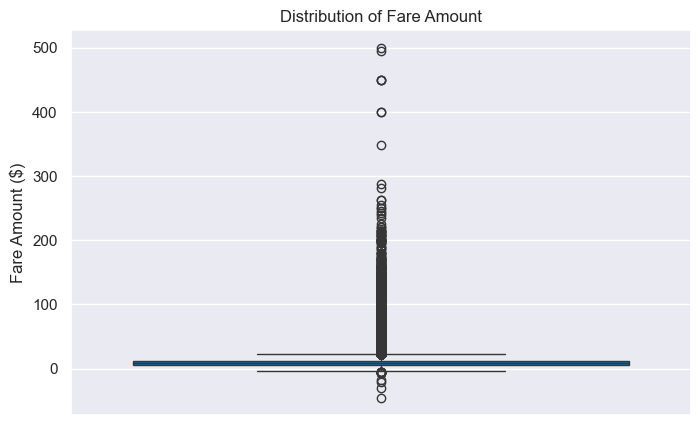

In [4]:
sns.boxplot(y="fare_amount",data=train)
plt.title("Distribution of Fare Amount")
plt.ylabel("Fare Amount ($)")
plt.show()

In [5]:
print(f"99% Quantile: {train["fare_amount"].quantile(0.99)}\nMedian: \
{train["fare_amount"].median()}")
print(train["fare_amount"].value_counts(bins=[0,50,100,150,200]))

99% Quantile: 52.33
Median: 8.5
(-0.001, 50.0]    987191
(50.0, 100.0]      12375
(100.0, 150.0]       288
(150.0, 200.0]        70
Name: count, dtype: int64


In [6]:
# Data clening function to apply on training dataset
def missing_outliers(df):
    # 1.Creating a clone for reporducibility
    df_clean = df.copy()
    # 2. Dropping Missing values
    columns_to_drop = ["dropoff_longitude","dropoff_latitude"]
    df_clean = df_clean.dropna(subset=columns_to_drop)
    # 3. Removing negative prices
    df_clean= df_clean[df_clean['fare_amount']>0]
    # 4. Removing outliers by quantile method
    df_clean = df_clean[df_clean['fare_amount']<100]
    #5. Remoming the extreme passenger count
    df_clean = df_clean[~df_clean["passenger_count"].isin([208,0])]
    return df_clean.reset_index(drop=True)
train_clean = missing_outliers(train)

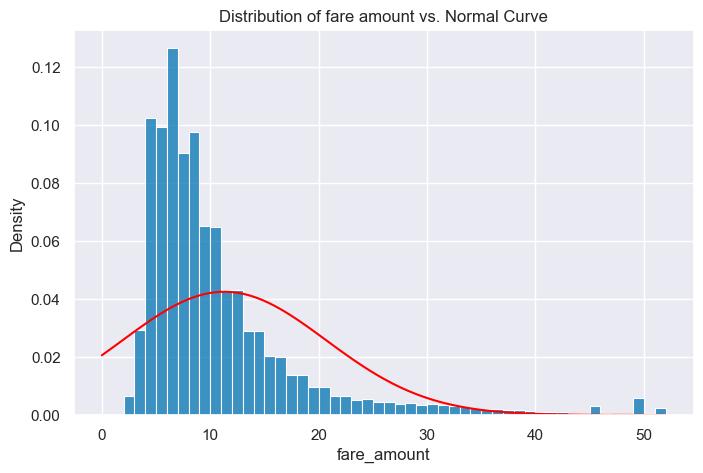

In [7]:
sns.histplot(x="fare_amount",bins=np.linspace(0,52,53),stat="density",data=train_clean)
x_smooth = np.linspace(0,52,106)
normal_dist= norm.pdf(x_smooth,train_clean['fare_amount'].mean(),
                      train_clean['fare_amount'].std())
plt.plot(x_smooth,normal_dist,color="red")
plt.title("Distribution of fare amount vs. Normal Curve")
plt.show()

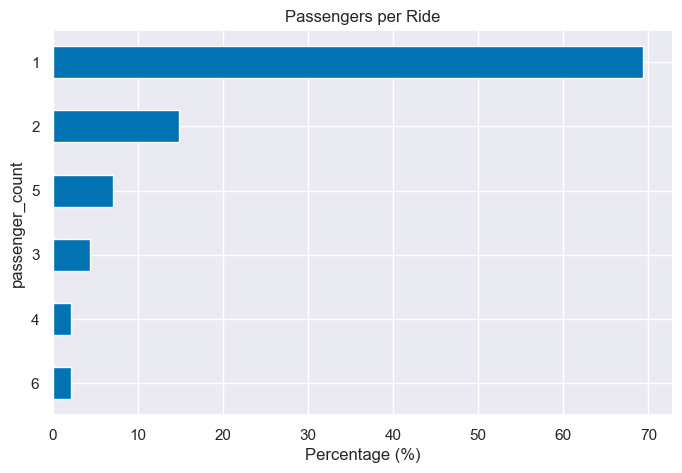

In [8]:
(train_clean["passenger_count"].value_counts(normalize=True,ascending=True)*100).\
    plot(kind="barh")
plt.title("Passengers per Ride")
plt.xlabel("Percentage (%)")
plt.show()

In [9]:
print(f"Number of rows with either 0 and one instance of 208 passengers are : \
{len(train_clean[train_clean['passenger_count'].isin([208,0])])}\n")
train_clean=train_clean[~train_clean["passenger_count"].isin([208,0])]

Number of rows with either 0 and one instance of 208 passengers are : 0



- The fare distribution is highly right-skewed due to high-value trips ($200) while the median is much lower (~8.5).
- To keep balance between extreme outliers and robustness, I will keep upper limit to 100 as there are 12375 records between 50 and 100.
- Log transformation (Log1p) will help to stabilize variance, reduce skewness during modelling.
- Invalid values in fare columns are removed (e.g., negative price).
- Invalid passenger counts such as 0 and extreme values (e.g., 208) are also removed as data quality issues.

In [10]:
def date_transform(df):
    df_clean=df.copy()
    df_clean["pickup_datetime"]=pd.to_datetime( df_clean["pickup_datetime"],errors="coerce")
    df_clean["hour"]=df_clean["pickup_datetime"].dt.hour
    df_clean["year"]=df_clean["pickup_datetime"].dt.year
    df_clean["day_of_week"]=df_clean["pickup_datetime"].dt.day_of_week
    return df_clean
train_clean=date_transform(train_clean)

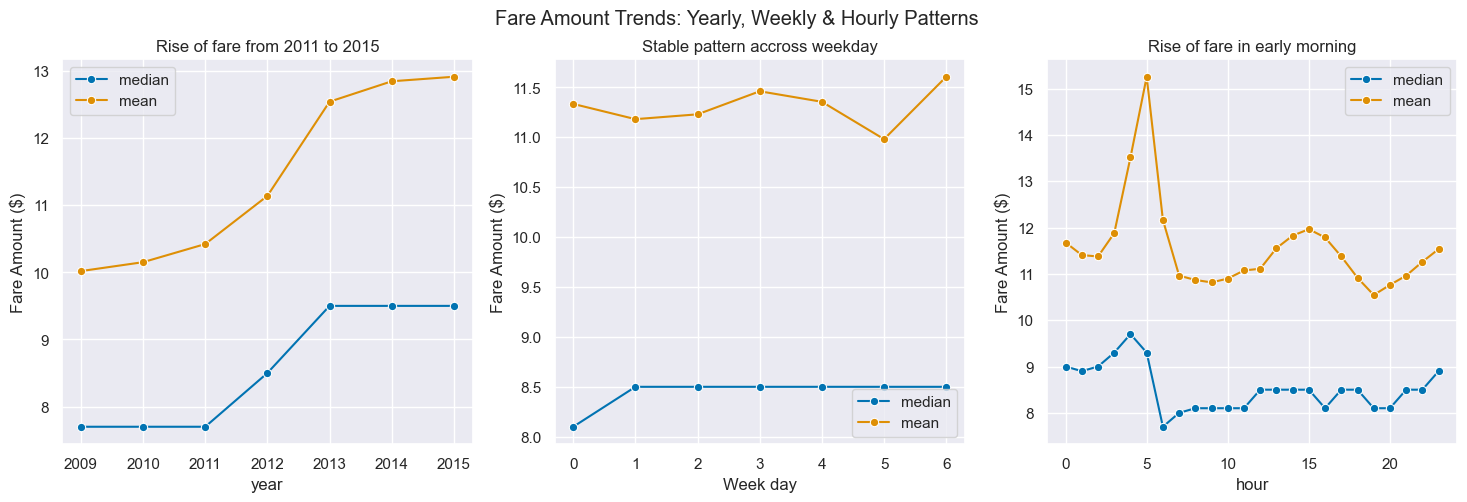

In [11]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(18, 5))
sns.lineplot(x="year",y="fare_amount",data=train_clean,marker="o",
             estimator="median",label="median",errorbar=None,ax=ax1)
sns.lineplot(x="year",y="fare_amount",data=train_clean,marker="o",label="mean",
             errorbar=None,ax=ax1)
sns.lineplot(x="day_of_week",y="fare_amount",marker="o",
             estimator="median",label="median",data=train_clean,errorbar=None,ax=ax2)
sns.lineplot(x="day_of_week",y="fare_amount",marker="o",
             label="mean",data=train_clean,errorbar=None,ax=ax2)
sns.lineplot(x="hour",y="fare_amount",data=train_clean,
             marker="o",estimator="median",label="median",errorbar=None,ax=ax3)
sns.lineplot(x="hour",y="fare_amount",data=train_clean,
             marker="o",label="mean",errorbar=None,ax=ax3)
ax1.set_title("Rise of fare from 2011 to 2015")
ax2.set_title('Stable pattern accross weekday')
ax3.set_title('Rise of fare in early morning')
ax1.set_ylabel("Fare Amount ($)")
ax2.set_ylabel("Fare Amount ($)")
ax3.set_ylabel("Fare Amount ($)")
ax2.set_xlabel('Week day')
plt.suptitle("Fare Amount Trends: Yearly, Weekly & Hourly Patterns")
plt.show()

- Yearly: As both mean and median fares increase over time, confirming a real upward trend from 2001 to 2013.
- Weekly: Median fare is almost flat across weeks with small fluctuation due to outliers.
- Hourly: Mean and median shows a sharp spike in early morning, indicating morning airport bookings.

In [12]:
def coordinate_outlier(df):
    df_clean = df.copy()
    latitude_range = (40.47, 40.92) # Filtering NYC co-ordiantes only 
    longitude_range = (-74.27, -73.69)
    co_ordinates_boundary = (df_clean["pickup_latitude"].between(*latitude_range)&\
                          df_clean['pickup_longitude'].between(*longitude_range))&\
                          (df_clean['dropoff_latitude'].between(*latitude_range)&\
                          df_clean['dropoff_longitude'].between(*longitude_range))
    df_clean = df_clean[co_ordinates_boundary]
    return df_clean.reset_index(drop=True)
train_clean = coordinate_outlier(train_clean)

In [13]:
def airportbound(df):
    df_clean=df.copy()
    JFK=(df_clean["pickup_latitude"].between(40.63, 40.66)&\
         df_clean['pickup_longitude'].between(-73.80, -73.75))|\
         (df_clean['dropoff_latitude'].between(40.63, 40.66)&\
          df_clean['dropoff_longitude'].between(-73.80, -73.75))
    EWR = (df_clean["pickup_latitude"].between(40.67, 40.71)&\
         df_clean["pickup_longitude"].between(-74.19, -74.15))|\
        (df_clean["dropoff_latitude"].between(40.67, 40.71)&\
         df_clean["dropoff_longitude"].between(-74.19, -74.15))
    LGA = (df_clean["pickup_latitude"].between(40.76, 40.79)&\
         df_clean["pickup_longitude"].between(-73.89, -73.85))|\
        (df_clean["dropoff_latitude"].between(40.76, 40.79)&\
         df_clean["dropoff_longitude"].between(-73.89, -73.85))
    
    df_clean["is_airport"]=(JFK|EWR|LGA).astype(int)
    return df_clean
train_clean=airportbound(train_clean)   

In [14]:
def haversign_distance(df):
    """
    d = 2R · arcsin( √[ sin²((lat₂ - lat₁)/2) + cos(lat₁)·cos(lat₂)·sin²(
    (lon₂ - lon₁)/2) ] )
    6371 is earth radius in Km
    """
    df_clean=df.copy()
    lat1=np.radians(df_clean['pickup_latitude'])
    lat2=np.radians(df_clean['dropoff_latitude'])
    lon1=np.radians(df_clean['pickup_longitude'])
    lon2=np.radians(df_clean['dropoff_longitude'])
    dlat= lat2-lat1
    dlon= lon2-lon1
    # Haversine formula
    a= np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c= 2 * np.arcsin(np.sqrt(a))
    R=6371
    df_clean["distance_km"]=c*R
    return df_clean
train_clean=haversign_distance(train_clean)

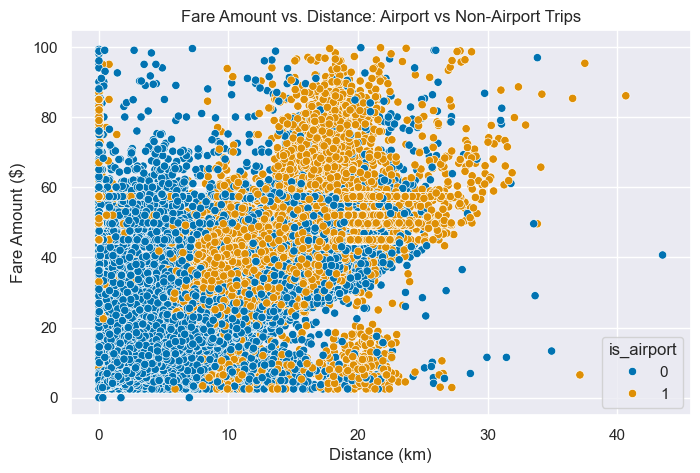

In [15]:
sns.scatterplot(x="distance_km",y="fare_amount",hue="is_airport",data=train_clean)
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare Amount vs. Distance: Airport vs Non-Airport Trips")
plt.show()

- Fare increases with distance but the airport trips have higher fares for similar distances, indicating different pricing behavior.
- There are flat-line cluster present near $40-60 range in the airport bound traffic, indicating non-linear relationship between fare and distance.
- Additionally, the fares along the y-axis (near zero distance) indicates a **base fare component**, with more surcharge for airport bound traffic.

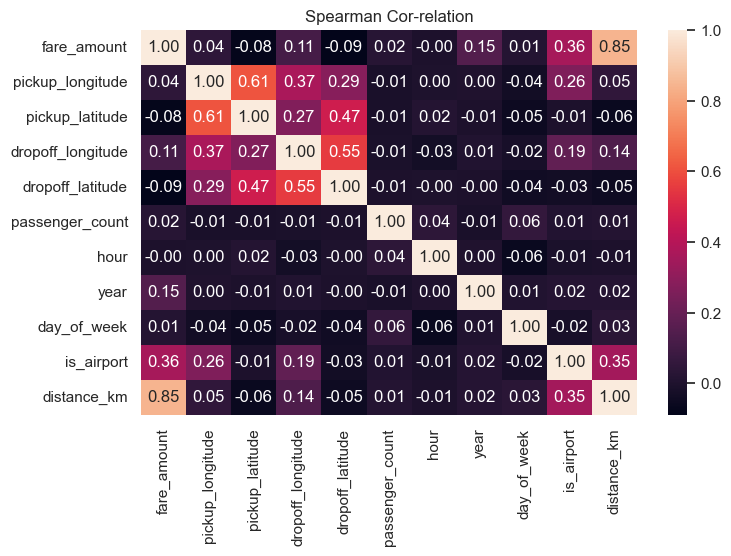

In [16]:
sns.heatmap(train_clean.corr(numeric_only=True,method="spearman"),annot=True,fmt=".2f")
plt.title("Spearman Cor-relation")
plt.show()

- As the data sets has non-linear relation, using spearman co-relations shows fare has most positive co-relation with distance followed by airport bound or not, year etc.

## Modelling
### Base-line model

In [17]:
# 1. Feature selection
X=train_clean.drop(['key','fare_amount','pickup_datetime'],axis=1)

# 2. Target selection
y=train_clean["fare_amount"]

# 3. 20% as test set/unseen data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 4. Looping 3 linear model for comparison
models= {"Linear Regression": LinearRegression(),
         "Ridge Regression": Ridge(random_state=42,alpha=10), # L2 penalty to co-efficients
         "XGBRegressor": XGBRegressor(random_state=42,objective="reg:squarederror",
                                      n_estimators=100)} # Number of trees
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    rmse= root_mean_squared_error(y_test,y_pred)
    R2=r2_score(y_test,y_pred)
    print(f"Model: {name}\nRMSE: {rmse:.2f} R2: {R2:.2f}")

Model: Linear Regression
RMSE: 4.23 R2: 0.80
Model: Ridge Regression
RMSE: 4.23 R2: 0.80
Model: XGBRegressor
RMSE: 3.40 R2: 0.87


- An 80/20 splits are used. XGBoost has lower RMSE and higher R2 than the both linear models even after adding penalty. The fare has non-linear relationship with features so tree based models are better suited to capture these patterns.  

## Hyperparemeter tuninng with K-Fold cross validation

In [18]:
# 1. Cross validation with 5 split for robustness and to reduce biasness
kfold=KFold(n_splits=5,shuffle=True,random_state=42)

# 2. hyperparameter tuning of XGBoost regression parameters
xgb=XGBRegressor(random_state=42,objective="reg:squarederror") # fixed seed for reproducibility
param_gid={"n_estimators":[200,400,600], #Number of trees
           "max_depth":[3,4,5], # Maximum depth in each tree
           "learning_rate":[0.01,0.1,0.2], # Step size
           "subsample":[0.7,0.8,0.9], # Fraction of traing data used per tree
           "colsample_bytree":[0.7,0.8,0.9] # Fraction of feature used per tree
           } 

# 3. Randomized Seach of all 64 parameter combinations across 5 splits with 10 iterrations
xgb_gridcv=RandomizedSearchCV(xgb,param_gid,cv=kfold,n_iter=20,random_state=42,
                              scoring="neg_root_mean_squared_error")

# 4. Fitting and predicting using the best estimator and parameters
xgb_gridcv.fit(X_train,y_train)
y_pred=xgb_gridcv.predict(X_test)

# 5. Results
rmse = root_mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test,y_pred)
cv_rmse = -xgb_gridcv.best_score_
print(f"Tuned Parameters for the best estimator:{xgb_gridcv.best_params_}")
print(f"Cross Validations RMSE: {cv_rmse:.2f}\nTest RMSE: {rmse:.2f}\nR2 Score: {R2:.2f}")

Tuned Parameters for the best estimator:{'subsample': 0.9, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Cross Validations RMSE: 3.38
Test RMSE: 3.40
R2 Score: 0.87


- The model generalizes well with minimal overfitting as the diffence between Cross Validations RMSE and Test RMSE is only 0.04.

### Feature Importance

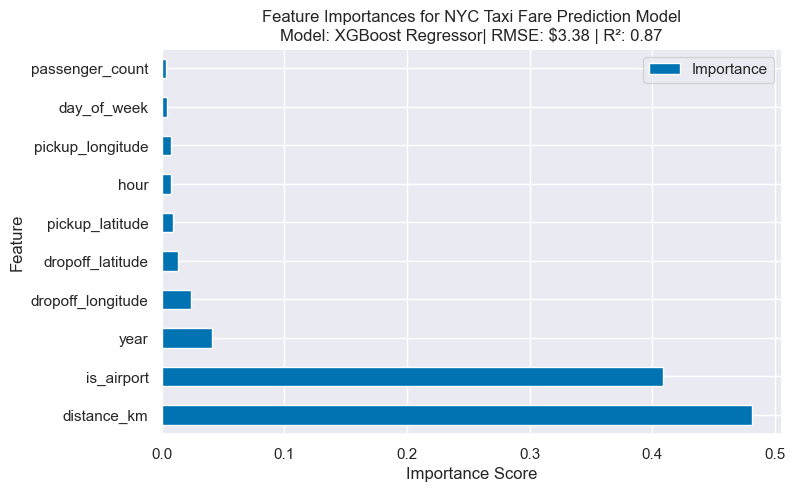

In [19]:
ax=pd.DataFrame({"Feature":X.columns,"Importance":xgb_gridcv.\
    best_estimator_.feature_importances_}).\
    sort_values(by="Importance",ascending=False).plot.barh("Feature","Importance")
plt.title("Feature Importances for NYC Taxi Fare Prediction Model\nModel: XGBoost Regressor| RMSE: $3.38 | R²: 0.87")
plt.xlabel("Importance Score")
plt.show()

- The model feature importance indicates that the distance is the most dominant factor in fare prediction, along with airport trips as  the secondary driver.
- Other temporal features such as time, year and passenger has less importance.
- These concluse that fare is largely determined by spatial and pricing rules than temporal patterns.

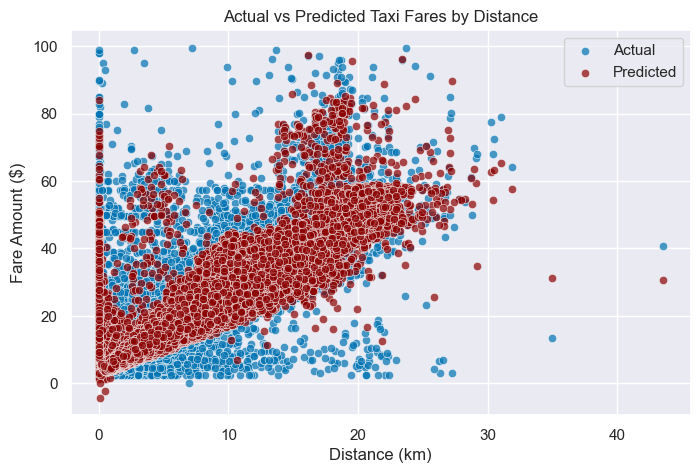

In [20]:
sns.scatterplot(x=X_test["distance_km"],y=y_test,label="Actual",alpha=0.7)
sns.scatterplot(x=X_test["distance_km"],y=y_pred,label="Predicted",
                color="darkred",alpha=0.7)
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.title("Actual vs Predicted Taxi Fares by Distance")
plt.show()

- The scatter plot shows the XGBoost model captures oveall relationship between distance and fare, while fail to captute noise like base base fare, short distance.

## Kaggle Submission

In [21]:
## Applying same transformation on test except # missing_outliers and # coordinate_outlier that reduce rows
# 1.Tranformation
test=date_transform(test) # For date transformation
test=airportbound(test) # For creating 'is_airport' column
test=haversign_distance(test) # For creating 'distance_km' column
# 2. Refitting with Gridsearch best estimator
xgb_gridcv.fit(X, y)
#3. Alignment
test_final = test[X.columns]
#4. Predict
test["fare_amount"] = xgb_gridcv.predict(test_final) 
test[["key","fare_amount"]].to_csv('submission.csv', index=False)
print("Final Submission Generated!")

Final Submission Generated!
